In [1]:
print("Notebook working")

Notebook working


# Explainable Fraud Alert Prioritization - Exploratory Data Analysis

## Objective
This notebook explores fraud transaction datasets to:
- understand customer transaction behavior
- identify fraud patterns
- analyze merchant risk
- prepare data for machine learning
- support explainable fraud prioritization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
customers = pd.read_csv("../data/raw/raw/customers.csv")
merchants = pd.read_csv("../data/raw/raw/merchants.csv")
transactions = pd.read_csv("../data/raw/raw/transactions.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [4]:
customers = pd.read_csv("../data/raw/raw/customers.csv")
merchants = pd.read_csv("../data/raw/raw/merchants.csv")
transactions = pd.read_csv("../data/raw/raw/transactions.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [5]:
import os

os.getcwd()

'C:\\Users\\Mirza Saif Baig\\Documents\\jpmorgan-fraud-alert-ai\\notebooks'

In [6]:
import os

os.listdir("../data/raw")

['raw']

In [7]:
customers = pd.read_csv("../data/raw/raw/customers.csv")
merchants = pd.read_csv("../data/raw/raw/merchants.csv")
transactions = pd.read_csv("../data/raw/raw/transactions.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [8]:
print("Customers Shape:", customers.shape)
print("Merchants Shape:", merchants.shape)
print("Transactions Shape:", transactions.shape)

Customers Shape: (5000, 8)
Merchants Shape: (5000, 4)
Transactions Shape: (5000, 17)


In [9]:
transactions.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score,is_night_flag,alert_generated,fraud_label
0,T9028450,2025-01-12 06:38:00,C100000,M100000,Card Present,70.46,US,4,0.747,1,1,2,3.0,0.474,1,0,0
1,T9050670,2025-01-20 04:18:00,C100001,M100001,P2P,36.12,DE,3,0.197,0,1,3,1488.6,0.218,1,1,0
2,T9015811,2025-03-16 21:19:00,C100002,M100002,Card Not Present,156.38,SG,10,0.393,0,3,6,136.2,0.632,0,0,0
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,3,5,30.5,0.632,0,0,0
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,1,3,3.1,0.097,0,0,0


In [10]:
transactions.columns

Index(['transaction_id', 'event_ts', 'customer_id', 'merchant_id', 'channel',
       'transaction_amount_usd', 'txn_country', 'txn_hour',
       'device_risk_score', 'new_device_flag', 'velocity_1h', 'velocity_24h',
       'geo_distance_km', 'merchant_risk_score', 'is_night_flag',
       'alert_generated', 'fraud_label'],
      dtype='str')

In [11]:
transactions['fraud_label'].value_counts()

fraud_label
0    4799
1     201
Name: count, dtype: int64

In [12]:
fraud_percentage = (
    transactions['fraud_label']
    .value_counts(normalize=True) * 100
)

print(fraud_percentage)

fraud_label
0    95.98
1     4.02
Name: proportion, dtype: float64


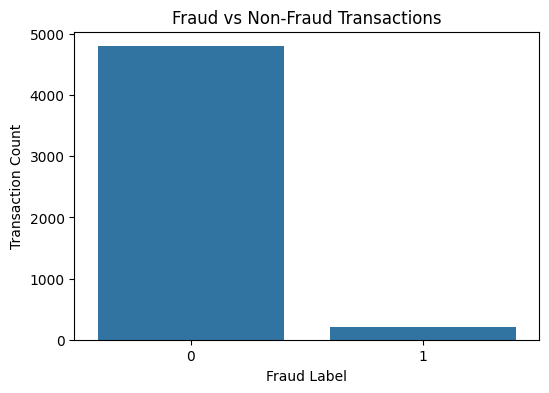

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='fraud_label',
    data=transactions
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Count")

plt.show()

## Fraud Distribution Insight

The dataset shows a class imbalance between fraudulent and non-fraudulent transactions.

This is expected in real-world banking systems where fraud cases are relatively rare compared to legitimate transactions.

Class imbalance is an important consideration because:
- standard accuracy metrics may become misleading
- fraud detection models should prioritize recall
- false negatives are costly in financial systems

This insight will influence model selection and evaluation strategy later in the project.

In [14]:
transactions['transaction_amount_usd'].describe()

count    5000.000000
mean       90.439792
std       119.722456
min         2.120000
25%        27.022500
50%        54.960000
75%       109.072500
max      2845.700000
Name: transaction_amount_usd, dtype: float64

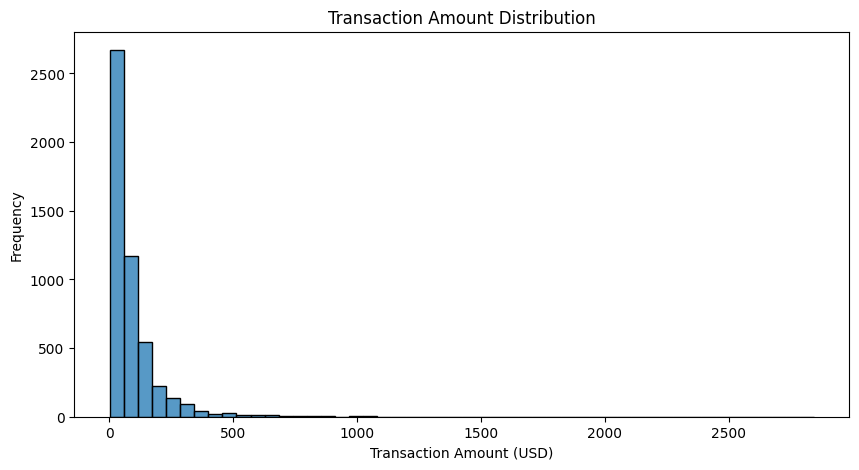

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    transactions['transaction_amount_usd'],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount (USD)")
plt.ylabel("Frequency")

plt.show()

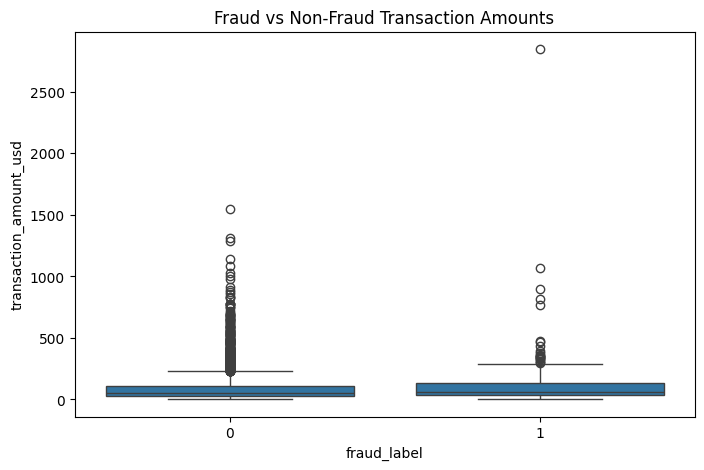

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='fraud_label',
    y='transaction_amount_usd',
    data=transactions
)

plt.title("Fraud vs Non-Fraud Transaction Amounts")

plt.show()

In [17]:
risk_features = [
    'device_risk_score',
    'velocity_1h',
    'velocity_24h',
    'geo_distance_km',
    'merchant_risk_score'
]

transactions[risk_features].describe()

,device_risk_score,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,0.288933,1.081200,3.46520,300.591200,0.256878
std,0.159261,1.034418,1.84745,1045.107312,0.163447
min,0.006000,0.000000,0.00000,0.000000,0.012000
25%,0.165000,0.000000,2.00000,6.800000,0.121000
50%,0.268000,1.000000,3.00000,17.100000,0.221000
75%,0.393250,2.000000,5.00000,39.400000,0.365000
max,0.895000,6.000000,13.00000,16211.800000,0.721000


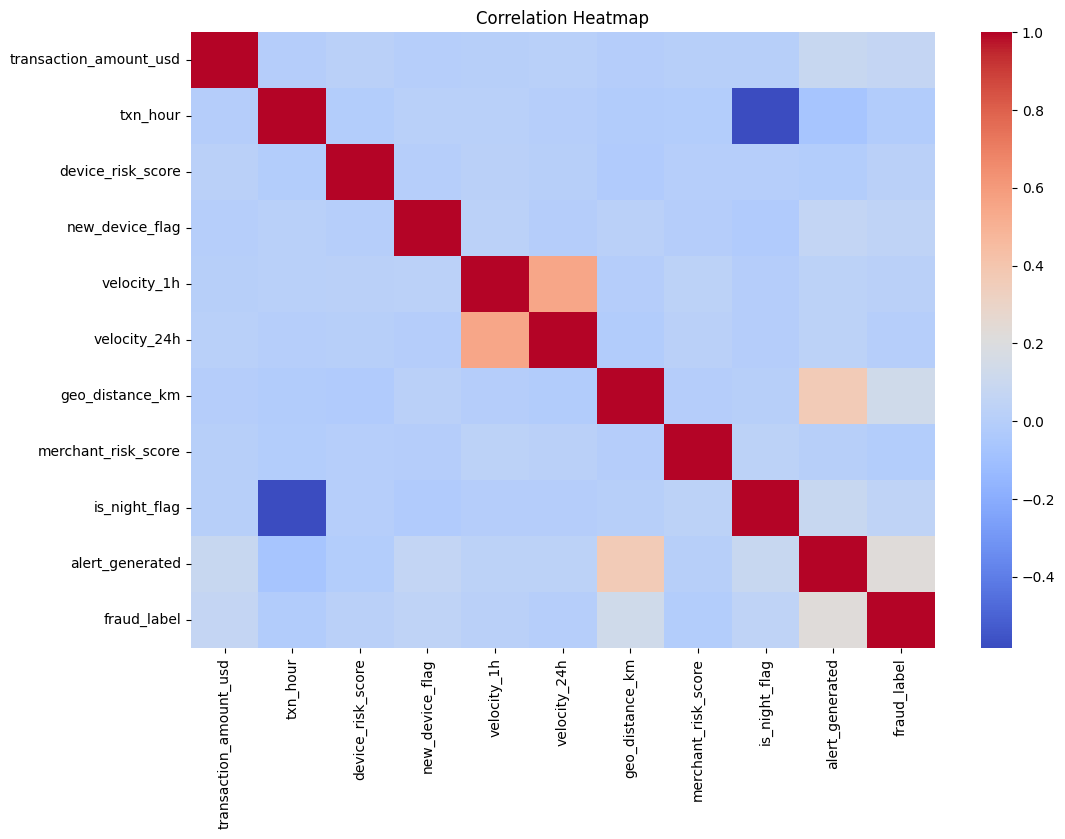

In [18]:
numeric_cols = transactions.select_dtypes(include=np.number)

correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

## Initial Fraud Risk Observations

Several features appear highly relevant for fraud detection:

- device risk score
- transaction velocity
- merchant risk score
- geographic transaction distance
- night transaction activity

These variables are commonly associated with suspicious transaction behavior in enterprise fraud detection systems.

The analysis suggests that behavioral and contextual transaction features may provide strong predictive power for fraud prioritization.